## Daily Challenge: Interactive Data Visualization with Matplotlib and Seaborn


In [2]:
import pandas as pd

df = pd.read_excel("/content/drive/MyDrive/BootGenAI/US_superstore_data.xls")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
df.isna().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [5]:
df.duplicated().sum()

np.int64(0)

In [8]:
df["Order Date"]= pd.to_datetime(df["Order Date"])
df["Ship Date"]= pd.to_datetime(df["Ship Date"])

# Add useful columns
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

dtype('int32')

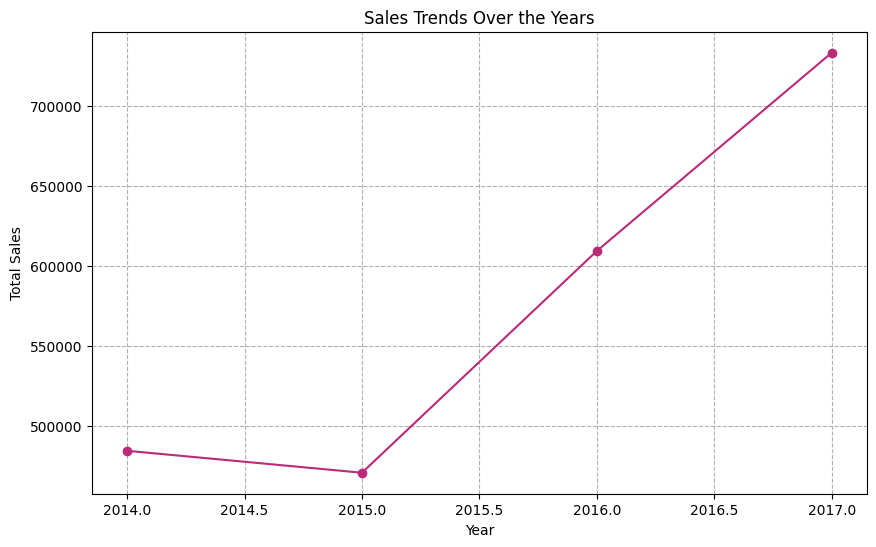

In [14]:
#Data Visualization with Matplotlib
import matplotlib.pyplot as plt

sales_by_year = df.groupby("Year")["Sales"].sum()

plt.figure(figsize=(10,6))
plt.plot(sales_by_year.index, sales_by_year.values, marker="o" , color="#BA2A78")
plt.title("Sales Trends Over the Years")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.grid(True, linestyle='--' )
plt.show()


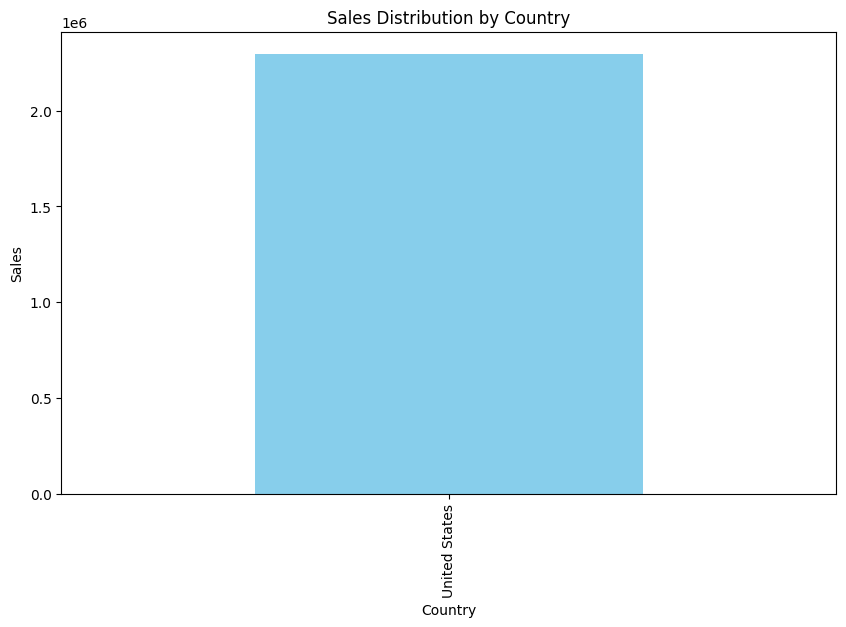

In [19]:
#Sales Distribution by Country (Map)
country_sales = df.groupby("Country")["Sales"].sum()

country_sales.plot(kind="bar", figsize=(10,6), color="skyblue")
plt.title("Sales Distribution by Country")
plt.ylabel("Sales")
plt.show()


/tmp/ipython-input-3700065215.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette="flare")


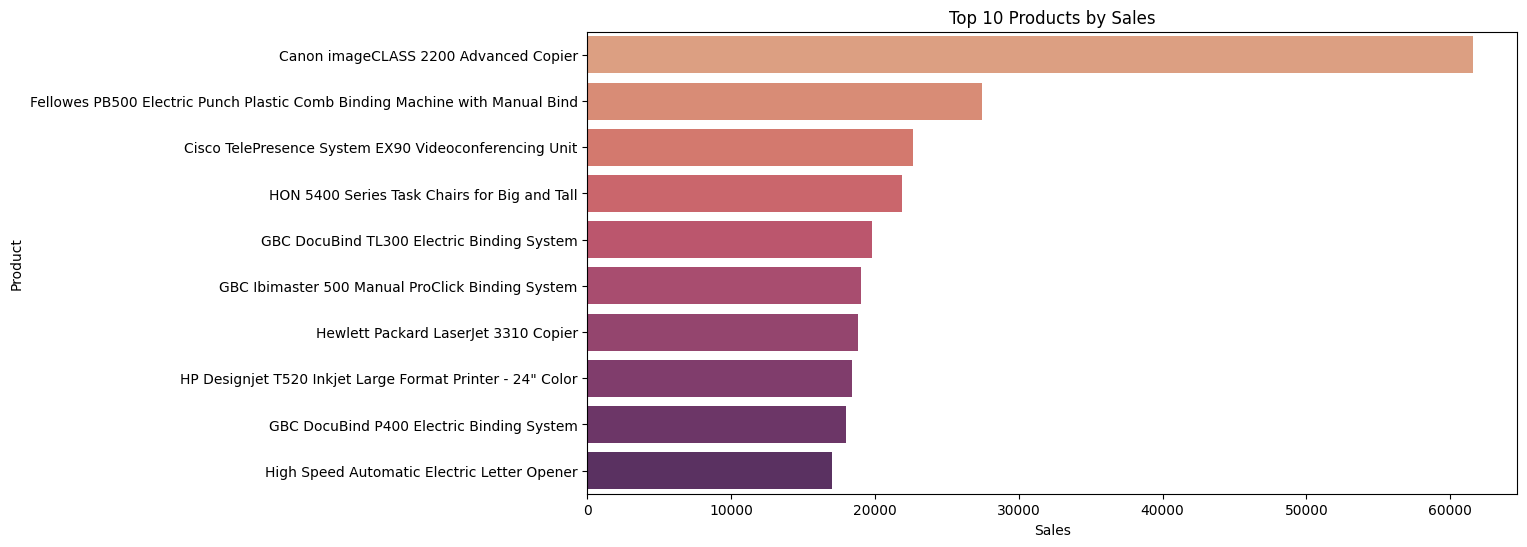

In [18]:
#Data Visualization with Seaborn
import seaborn as sns

top_products = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_products.values, y=top_products.index, palette="flare")
plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product")
plt.show()

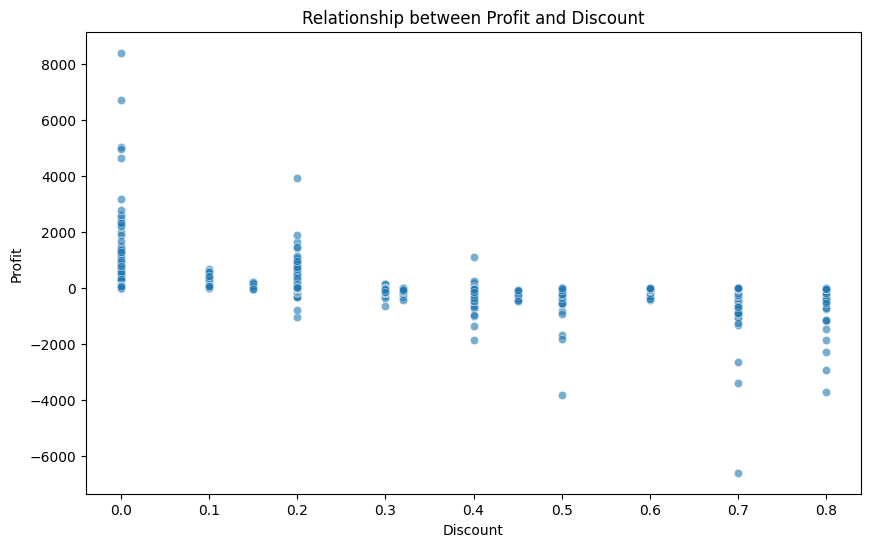

In [20]:
#Profit vs Discount Scatter Plot
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x="Discount", y="Profit", alpha=0.6)
plt.title("Relationship between Profit and Discount")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()


**Comparative Analysis :**

* Matplotlib → great for interactive exploration (zoom, pan, dynamic updates).

* Seaborn → elegant static plots with built‑in statistical styling.

*Observation: Use Matplotlib for dashboards and exploratory analysis; Seaborn for polished reports.*